# Logistic Regression — Credit Card Fraud Detection

## Overview
In this notebook, we apply **Logistic Regression** to detect fraudulent credit card transactions using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) from Kaggle.

We cover the full machine learning workflow:
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Handling class imbalance with undersampling
- Model training (from scratch and with scikit-learn)
- Evaluation using accuracy, precision, recall, and F1-score

## What is Logistic Regression?
Logistic Regression is a classification algorithm that models the probability of a binary outcome using the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n$.

The model is trained by minimizing the **Binary Cross-Entropy Loss**:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load Data

In [4]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Class distribution
print("Class Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


/var/folders/_9/05gpf5dd4j70lgvrsl7wcwv80000gn/T/ipykernel_21450/460743642.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='coolwarm')


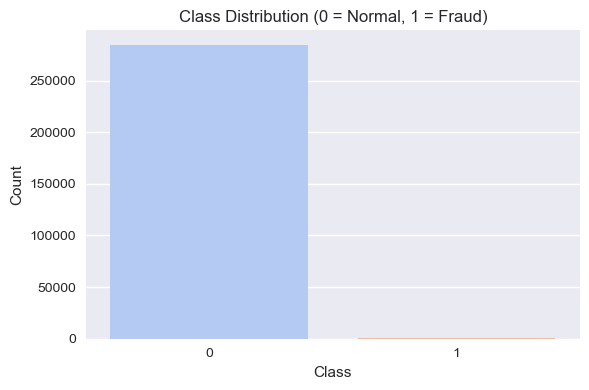

In [6]:
# Visualize class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='coolwarm')
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/var/folders/_9/05gpf5dd4j70lgvrsl7wcwv80000gn/T/ipykernel_21450/270908469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='coolwarm')


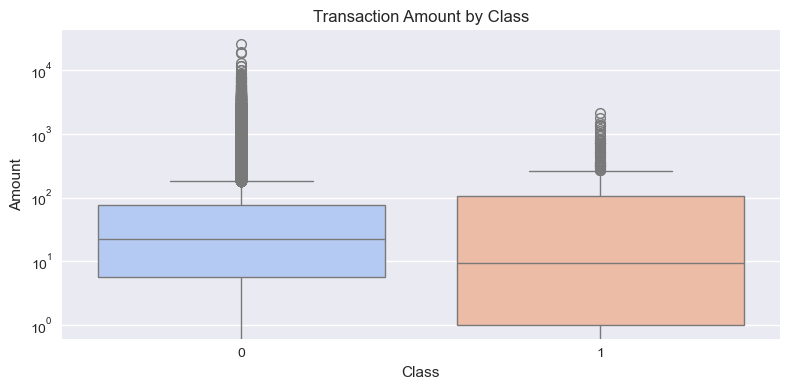

In [7]:
# Transaction amount by class
plt.figure(figsize=(8, 4))
sns.boxplot(x='Class', y='Amount', data=df, palette='coolwarm')
plt.title('Transaction Amount by Class')
plt.yscale('log')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [8]:
# Handle class imbalance via undersampling
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced['Class'].value_counts())

Balanced dataset shape: (984, 31)
Class
0    492
1    492
Name: count, dtype: int64


In [9]:
# Features and target
X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (787, 30)
Test set size: (197, 30)


## 4. Logistic Regression from Scratch

In [10]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)
            loss = -np.mean(y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9))
            self.losses.append(loss)
            dw = X.T @ (y_pred - y) / n_samples
            db = np.mean(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Train
model_scratch = LogisticRegressionScratch(lr=0.1, epochs=1000)
model_scratch.fit(X_train_scaled, y_train)

# Evaluate
y_pred_scratch = model_scratch.predict(X_test_scaled)
print("From Scratch:")
print(classification_report(y_test, y_pred_scratch))

From Scratch:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93        87
           1       0.99      0.90      0.94       110

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



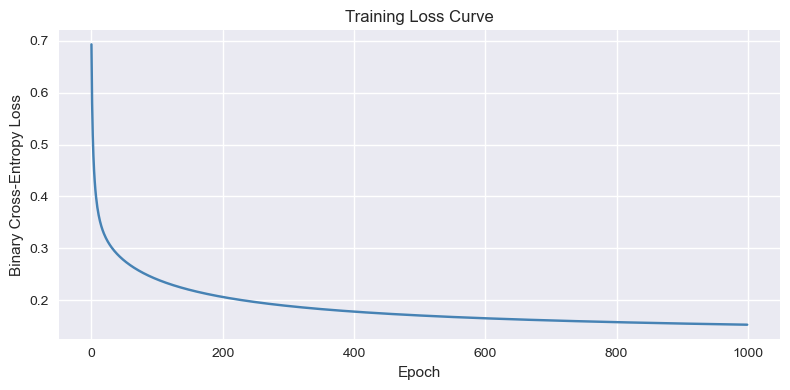

In [11]:
# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(model_scratch.losses, color='steelblue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.tight_layout()
plt.show()

## 5. Logistic Regression with Scikit-Learn

In [12]:
model_sklearn = SklearnLR(max_iter=1000, random_state=42)
model_sklearn.fit(X_train_scaled, y_train)

y_pred_sklearn = model_sklearn.predict(X_test_scaled)
print("Scikit-Learn:")
print(classification_report(y_test, y_pred_sklearn))

Scikit-Learn:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        87
           1       0.99      0.91      0.95       110

    accuracy                           0.94       197
   macro avg       0.94      0.95      0.94       197
weighted avg       0.95      0.94      0.94       197



## 6. Model Evaluation & Visualization

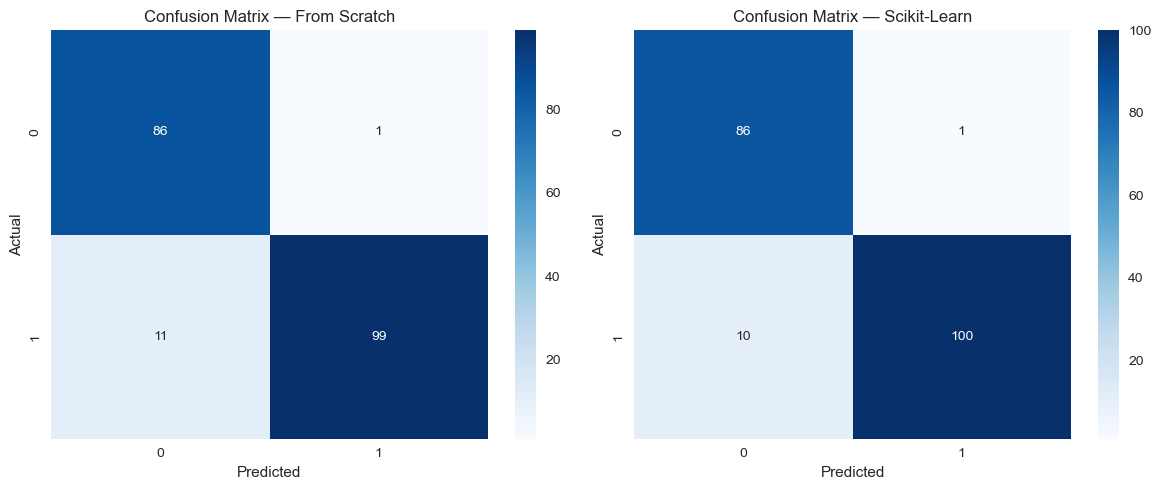

In [13]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_scratch, y_pred_sklearn],
                               ['From Scratch', 'Scikit-Learn']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

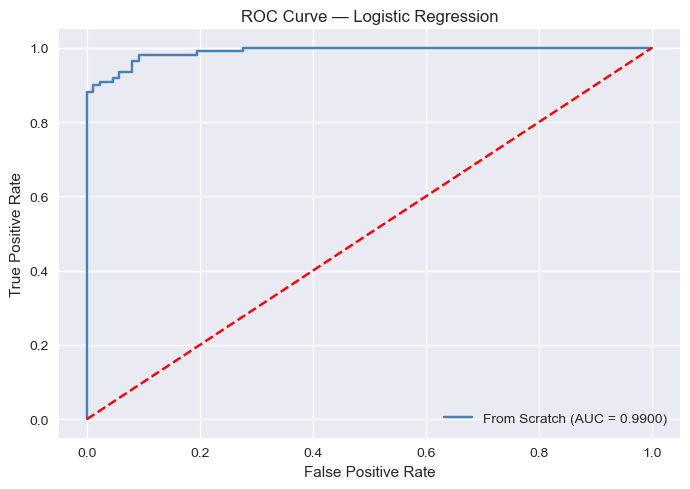

In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model_scratch.predict_proba(X_test_scaled))
auc = roc_auc_score(y_test, model_scratch.predict_proba(X_test_scaled))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'From Scratch (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

In this notebook, we trained a Logistic Regression model to detect fraudulent credit card transactions.

Key takeaways:
- The dataset is highly imbalanced (~0.17% fraud). We addressed this with undersampling.
- Our from-scratch implementation using gradient descent achieves performance comparable to scikit-learn.
- High AUC score indicates the model effectively distinguishes fraud from normal transactions.
- Future improvements could include SMOTE oversampling, regularization tuning, or more powerful classifiers like Random Forests.